In [1]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from fizinfo import *

In [2]:
#Gy / 6. feladat [16 p]
#
# Valamikor az elképzelt jövőben emberek élnek a Hold felszínén, 
# ahol a gravitációs gyorsulás értéke 1,625 m/s^2. Itt is rendeznek sportversenyeket, 
# és légüres térben kell egy labdát messzire hajítaniuk, 
# de az eldobás pillanata után 5 másodperccel bekapcsolják a mesterséges gravitációt a sportpályán, 
# és hirtelen a földi 9,81 m/s^2 erősségű gravitációt fogja a labda érezni.
#
# Az egyik versenyző 16 m/s kezdősebességet tud a labdának adni, és a labdát 180 cm magasan engedi el.
#
# a) Először a vízszintessel 45 fokos szöget bezáróan hajítja a labdát. 
# Ábrázolja ekkor a labda pályáját legalább annyi ideig, amíg becsapódik a felszínbe! (3 p)
#
# b) Mi ilyenkor a dobás távolsága és az elért legnagyobb magasság? (3 p)
#
# c) Milyen irányt válasszon a 45 fokos helyett, hogy a labda a legmesszebb repüljön? (5 p)
#
# d) Mennyi a minimális és maximális eldobási szög, 
# ha a labdának át kell repülnie egy, a dobótól 30 m-re levő, 40 m magas fal felett?
#

In [3]:
# labda súlyát feltételezzuk 0.3kg
m_ball = 0.3

# Közegellenállás nélküli gravitációs modell holdi gravitáció

def create_grav_F_m(m, g=1.625):
    """
    Létrehozza egy állandó tömegű test tömegfüggvényét és gravitációs erőfüggvényét.

    A modellben az egyetlen ható erő a gravitáció:
        F_g = (0, -m·g)

    Paraméterek:
        m : test tömege [kg]
        g : gravitációs gyorsulás [m/s²]

    Visszatérés:
        force_fun : erőfüggvény, amely az eredő erőt adja vissza [N]
        mass_fun  : tömegfüggvény, amely az aktuális tömeget adja vissza [kg]
    """

    def mass_fun(t):
        """
        A test tömege időben állandó.

        A `t` paraméter azért szerepel, mert a numerikus dinamika
        általános tömegfüggvényt vár, amely akár időfüggő is lehet.
        """
        return m

    def force_fun(t, r, v, m):
        """
        Gravitációs erő 2D-ben.

        A modell homogén gravitációs mezőt feltételez, ezért az erő
        nem függ az időtől, a helyzettől vagy a sebességtől.
        """

        if t < 5:
            g=1.625
        else:
            g=9.81

        return np.array([0.0, -m * g], dtype=np.float64)

    return force_fun, mass_fun


# Gravitációs modell létrehozása 0.45 kg tömegű testre
F_grav_switch, m_const_switch = create_grav_F_m(m_ball)


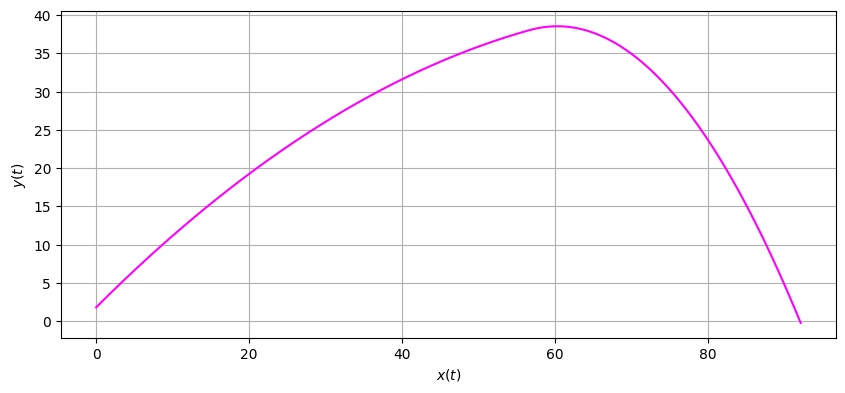

In [4]:
# Egyszerű leállási feltétel: ha y<0, akkor stop
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0

# Az egyik versenyző 16 m/s kezdősebességet tud a labdának adni, és a labdát 180 cm magasan engedi el.
# --- Kezdőfeltételek ---
kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 1.8  # kezdeti y pozíció [m] (1.8 m magasról indítjuk)

indulo_sebesseg     = 16.0   # kezdeti sebesség nagysága [m/s]
indulo_szog_fok     = 45.0   # indulási szög (vízszintestől) [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

# holdi szimuláció ------ 5> másodperc
ball_din = num_dinam(2)                     # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 100, 0.01)    # t ∈ [0, 30] s, dt = 0,001 s
ball_din.set_F_fun(F_grav_switch)           # erőfüggvény (gravitáció + drag + tolóerő)
ball_din.set_mass_fun(m_const_switch)      # tömegfüggvény (hajtóanyag-fogyás)
ball_din.set_r0_v0([kezdo_x, kezdo_y],     # kezdeti helyzet:  [0 m, 1.8 m]
                     [kezdo_vx, kezdo_vy]) # kezdeti sebesség: 55°, 10 m/s
ball_din.set_stop_cond(stop_ground_y)   # a fenti függvény megadása

# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)

# --- Pályagörbe megjelenítése ---
ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán


In [5]:
# b) Mi ilyenkor a dobás távolsága és az elért legnagyobb magasság? (3 p)

print(f'A labda távolsága: {ball_din.dist[-1]:.2f} m')
print(f'A labda elért legnagyobb magassága: {ball_din.r_y.max():.2f}')

A labda távolsága: 92.09 m
A labda elért legnagyobb magassága: 38.54


In [6]:
# c) Milyen irányt válasszon a 45 fokos helyett, hogy a labda a legmesszebb repüljön? (5 p)

def labda_szimulacio(szog_fok, dt=0.01, t_max=100.0):
    # A kezdősebesség nagysága minden szögnél ugyanaz, csak az x-y komponensek változnak.
    vx0 = indulo_sebesseg * np.cos(np.radians(szog_fok))
    vy0 = indulo_sebesseg * np.sin(np.radians(szog_fok))
    
    # Minden szöghöz új objektumot készítünk, hogy a korábbi futások ne keveredjenek bele.
    ball_szim = num_dinam(2)
    ball_szim.set_time_range(0.0, t_max, dt)
    ball_szim.set_F_fun(F_grav_switch)
    ball_szim.set_mass_fun(m_const_switch)
    ball_szim.set_r0_v0([kezdo_x, kezdo_y], [vx0, vy0])
    ball_szim.stop_cond = stop_ground_y
    
    # Teljes dinamikai számítás a becsapódásig.
    ball_szim.full_dinam_calc()
    
    return ball_szim

# A kilövési szögeket 0 és 90 fok között vizsgáljuk.
# A 0.1 fokos felbontás elég részletes ahhoz, hogy jól látszódjon a maximum helye.
szogek = np.arange(0.0, 90.0 + 0.1, 0.1)
max_tavolsagok = []

for szog in szogek:
    raketa = labda_szimulacio(szog)
    
    # A num_dinam a leálláskor az első talaj alatti pontot is eltárolhatja.
    # A "repülés közben" kifejezéshez ezért csak a y >= 0 pontokon nézzük a sebességet.
    max_tavolsagok.append(raketa.final_dist.max())

max_tavolsagok = np.array(max_tavolsagok)



Ahhoz, hogy a labda a legtávolabb repüljön 32.20°-os szögben kell elhajítani. 


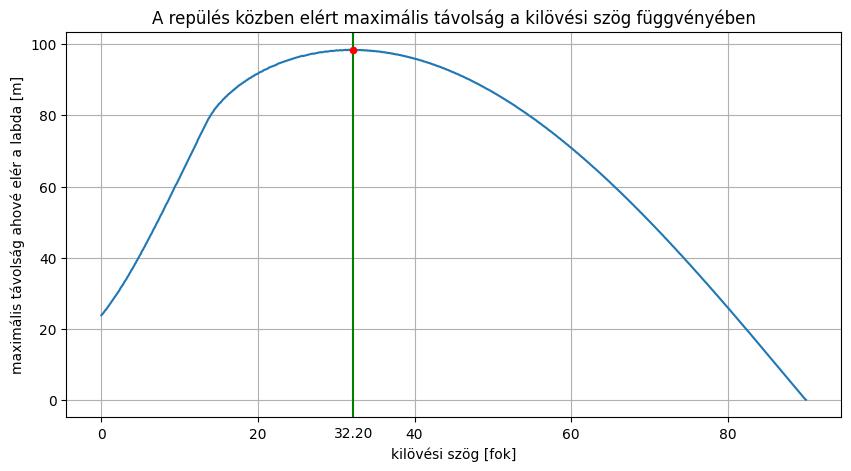

In [7]:
# c) Milyen irányt válasszon a 45 fokos helyett, hogy a labda a legmesszebb repüljön? (5 p)
# Az optimális szög 45 foknál kisebb, mert az első 5 másodpercben holdi gravitáció (g=1.625) hat,
# ami alatt a labda sokkal messzebbre jut vízszintesen — ezért érdemes laposabban lőni.
print(f'Ahhoz, hogy a labda a legtávolabb repüljön {szogek[max_tavolsagok.argmax()]:.2f}°-os szögben kell elhajítani. ')

optimalis_szog = szogek[max_tavolsagok.argmax()]
max_tavolsag = max_tavolsagok.max()

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)
ax1.scatter(optimalis_szog, max_tavolsag, color='red', s=20, zorder=5)
ax1.axvline(optimalis_szog, linestyle="solid", color='green', linewidth=1.5, label=f"Maximum: {optimalis_szog:.2f}°")
ax1.plot(szogek, max_tavolsagok)
ax1.text(optimalis_szog, -0.025, f"{optimalis_szog:.2f}", transform=ax1.get_xaxis_transform(), ha="center", va="top")
ax1.set_xlabel('kilövési szög [fok]')
ax1.set_ylabel('maximális távolság ahové elér a labda [m]')
ax1.set_title('A repülés közben elért maximális távolság a kilövési szög függvényében')
ax1.grid()

In [15]:
# d) Mennyi a minimális és maximális eldobási szög,
# ha a labdának át kell repülnie egy, a dobótól 30 m-re levő, 40 m magas fal felett?

fal_x = 30.0   # a fal vízszintes távolsága a dobótól [m]
fal_y = 40.0   # a fal magassága [m]

# A lehetséges eldobási szögeket 0° és 90° között vizsgáljuk, 0.1°-os felbontással.
szogek = np.arange(0.0, 90.0 + 0.1, 0.1)

jo_szogek = []             # ide kerülnek azok a szögek, amelyekkel a labda átrepül a fal felett

for szog in szogek:
    # Az adott szöghöz kiszámítjuk a labda teljes pályáját.
    ball_szim = labda_szimulacio(szog)

    # Megnézzük, hogy a pálya az x = fal_x helyen áthalad-e a fal magassága felett.
    atrepul, y_ertekek = ball_szim.flies_over_obstacle(fal_x, fal_y)

    # Ha a labda átrepül a fal felett, eltároljuk az adott eldobási szöget.
    if atrepul:
        jo_szogek.append(szog)

# Listák NumPy-tömbbé alakítása további számoláshoz.
jo_szogek = np.array(jo_szogek)


print(f"A minimális eldobási szög: {jo_szogek.min():.2f}°")
print(f"A maximális eldobási szög: {jo_szogek.max():.2f}°")

A minimális eldobási szög: 58.30°
A maximális eldobási szög: 76.20°
